In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)

n = 500

df = pd.DataFrame({
    "campaign": np.random.choice(["Campaign_A", "Campaign_B", "Campaign_C"], n),
    "channel": np.random.choice(["Facebook", "Google", "Instagram", "Email"], n),
    "impressions": np.random.randint(1000, 10000, n),
    "cost": np.random.randint(100, 5000, n),
    "country": np.random.choice(["USA", "UK", "Germany", "France"], n)
})

df["clicks"] = (df["impressions"] * np.random.uniform(0.05, 0.3, n)).astype(int)
df["conversions"] = (df["clicks"] * np.random.uniform(0.05, 0.2, n)).astype(int)

df.to_excel("marketing.xlsx", index=False)

In [3]:
df = pd.read_excel("marketing.xlsx")

df.head()

,campaign,channel,impressions,cost,country,clicks,conversions
0,Campaign_C,Google,8570,230,Germany,2182,132
1,Campaign_A,Google,8956,3083,Germany,1169,71
2,Campaign_C,Instagram,6124,4378,UK,341,34
3,Campaign_C,Google,6585,4559,UK,582,104
4,Campaign_A,Email,5777,138,USA,611,50


In [4]:
df.to_csv("marketing.csv", index=False)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   campaign     500 non-null    object
 1   channel      500 non-null    object
 2   impressions  500 non-null    int64 
 3   cost         500 non-null    int64 
 4   country      500 non-null    object
 5   clicks       500 non-null    int64 
 6   conversions  500 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 27.5+ KB


In [6]:
df.describe().round(4)

,impressions,cost,clicks,conversions
count,500.0000,500.0000,500.0000,500.0000
mean,5551.9800,2475.7880,960.4900,120.5800
std,2550.4212,1428.8522,644.2051,98.0848
min,1005.0000,101.0000,84.0000,5.0000
25%,3387.5000,1142.2500,433.7500,50.0000
50%,5494.0000,2374.0000,804.5000,92.0000
75%,7745.0000,3695.7500,1327.2500,158.2500
max,9996.0000,4989.0000,2875.0000,574.0000


In [7]:
df.isna().sum()

campaign       0
channel        0
impressions    0
cost           0
country        0
clicks         0
conversions    0
dtype: int64

In [8]:
df["CTR"] = df["clicks"] / df["impressions"].replace(0, np.nan)
df["CR"] = df["conversions"] / df["clicks"].replace(0, np.nan)
df["CPA"] = df["cost"] / df["conversions"].replace(0, np.nan)

In [9]:
channel_cr = df.groupby("channel")["CR"].mean().sort_values(ascending=False)

channel_cr

channel
Google       0.130534
Facebook     0.122611
Instagram    0.122581
Email        0.121649
Name: CR, dtype: float64

In [10]:
channel_cpa = df.groupby("channel")["CPA"].mean().sort_values(ascending=False)

channel_cpa

channel
Instagram    47.120385
Google       44.562355
Facebook     39.380235
Email        37.419626
Name: CPA, dtype: float64

In [11]:
country_cr = df.groupby("country")["CR"].mean().sort_values(ascending=False)

country_cr

country
France     0.129484
USA        0.124625
Germany    0.122265
UK         0.120741
Name: CR, dtype: float64

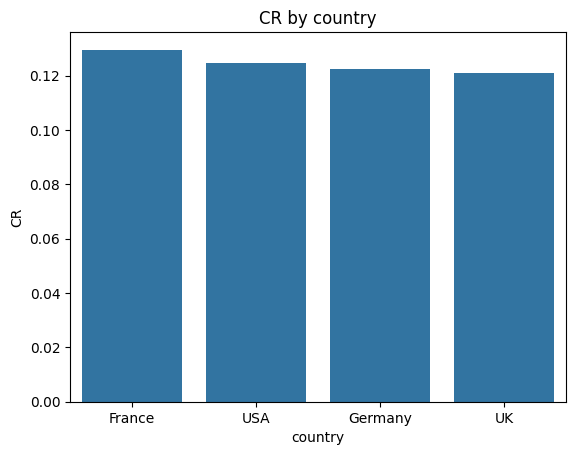

In [12]:
sns.barplot(
    x=country_cr.index,
    y=country_cr.values
)

plt.title("CR by country")
plt.ylabel("CR")
plt.show()

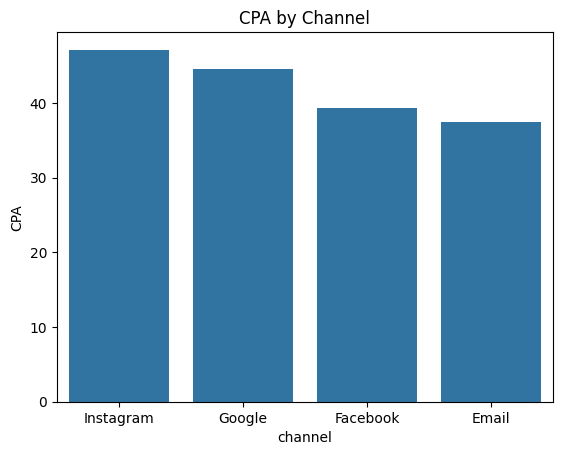

In [13]:
sns.barplot(
    x=channel_cpa.index,
    y=channel_cpa.values
)

plt.title("CPA by Channel")
plt.ylabel("CPA")
plt.show()

In [14]:
country_conv = df.groupby("country")["conversions"].sum().sort_values(ascending=False)

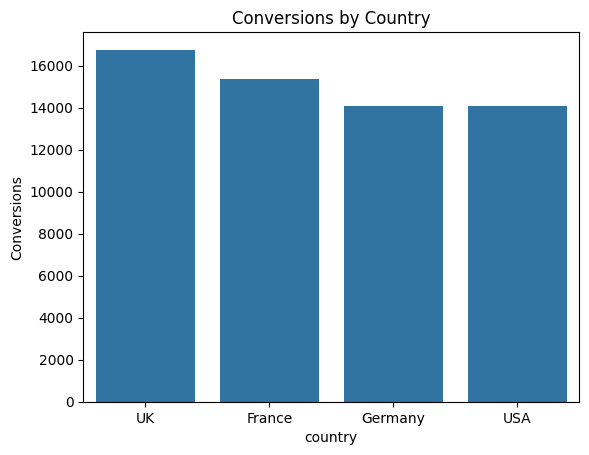

In [15]:
sns.barplot(
    x=country_conv.index,
    y=country_conv.values
)

plt.title("Conversions by Country")
plt.ylabel("Conversions")
plt.show()

In [16]:
df["avg_order_value"] = np.random.randint(20, 100, n)

In [17]:
df["Revenue"] = df["conversions"] * df["avg_order_value"]

df["ROI"] = (df["Revenue"] - df["cost"]) / df["cost"]

In [18]:
roi_channel = df.groupby("channel")["ROI"].mean().sort_values(ascending=False)

roi_channel

channel
Google       9.368993
Email        8.119502
Facebook     3.919570
Instagram    3.558435
Name: ROI, dtype: float64

In [20]:
channel_metrics = df.groupby("channel")[["CTR", "CR", "CPA", "ROI"]].mean()

best_channel = channel_metrics["ROI"].idxmax()

print("Best channel by ROI:", best_channel)

Best channel by ROI: Google


In [21]:
worst_channel = channel_metrics["ROI"].idxmin()

print("Worst channel by ROI: ", worst_channel)

Worst channel by ROI:  Instagram
